Homework 7
==========
<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌 Question 10.1 </br>
>Using the same crime data set uscrime.txt as in Questions 8.2 and 9.1, find the best model you can using 
(a) a regression tree model, and 
(b) a random forest model.  
In R, you can use the tree package or the rpart package, and the randomForest package.  For each model, describe one or two qualitative takeaways you get from analyzing the results (i.e., don’t just stop when you have a good model, but interpret it too).

</br>

In [194]:
library("kernlab")
library("kknn")
library("tidyr")
library("dplyr")
library("ggplot2")
library("plotly")
library("combinat")
library("ggplot2")
library("rpart")
library("randomForest")
library("rpart.plot")
library("caret")
library(data.table)
library(mltools)
####Functions
read_data<-function(data.path = character(), is_header= TRUE,delim = "\t"){
    # Reads the data from the given path and returns a data frame. In this case, the data is tab separated and has a header.
    data <- read.csv(data.path,header = is_header,sep = delim)
    return(data)

}


Regression tree:
rpart(formula = Crime ~ ., data = us_crime, method = "anova")

Variables actually used in tree construction:
[1] NW  Po1 Pop

Root node error: 6880928/47 = 146403

n= 47 

        CP nsplit rel error xerror    xstd
1 0.362963      0   1.00000 1.0673 0.26032
2 0.148143      1   0.63704 1.0533 0.21726
3 0.051732      2   0.48889 1.0308 0.24002
4 0.010000      3   0.43716 1.0195 0.24125

Regression tree:
rpart(formula = Crime ~ ., data = us_crime, method = "anova")

Variables actually used in tree construction:
[1] NW  Po1 Pop

Root node error: 6880928/47 = 146403

n= 47 

        CP nsplit rel error xerror    xstd
1 0.362963      0   1.00000 1.0673 0.26032
2 0.148143      1   0.63704 1.0533 0.21726
3 0.051732      2   0.48889 1.0308 0.24002
4 0.010000      3   0.43716 1.0195 0.24125


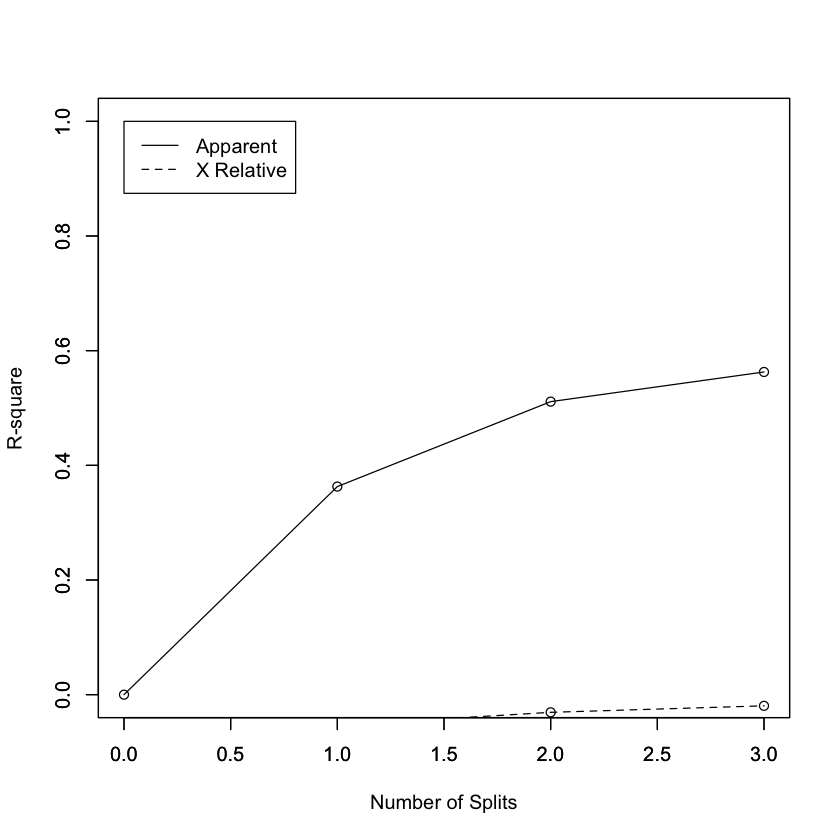

RMSE    Rsquared         MAE 
252.9856423   0.5628378 186.9823156


Call:
 randomForest(formula = Crime ~ ., data = us_crime, method = "anova") 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 5

          Mean of squared residuals: 85077.7
                    % Var explained: 41.89

Call:
 randomForest(formula = Crime ~ ., data = us_crime, method = "anova",      ntree = 1000) 
               Type of random forest: regression
                     Number of trees: 1000
No. of variables tried at each split: 5

          Mean of squared residuals: 87727.56
                    % Var explained: 40.08


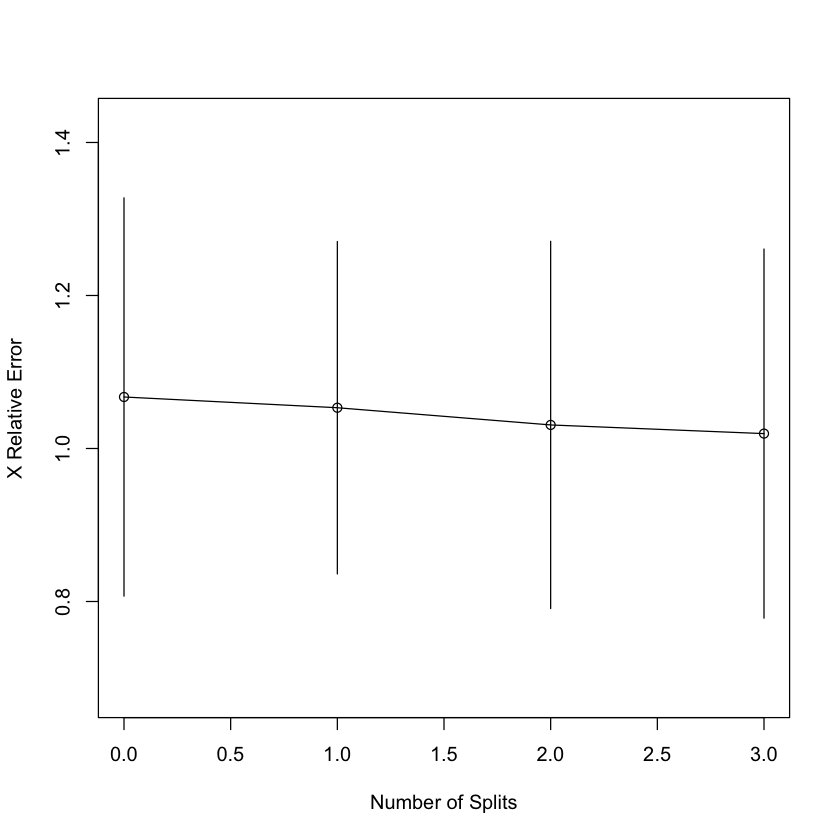

In [79]:
set.seed(123)
data_path<-"/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/01_Data/Homework7_ISYE6501/uscrime.txt"

us_crime<-read_data(data.path=data_path)


regression_classification<-rpart(formula = Crime ~. ,data= us_crime, method = "anova")

p<-predict(regression_classification, newdata = us_crime)

printcp(regression_classification)
rsq.rpart(regression_classification)
postResample(pred = p, obs = us_crime$Crime)

random_forest_model<-randomForest::randomForest(formula = Crime ~. ,data= us_crime, method = "anova")


print(random_forest_model)


random_forest_model_1000trees<-randomForest::randomForest(formula = Crime ~. ,data= us_crime, method = "anova",ntree = 1000)

print(random_forest_model_1000trees)



<link rel="stylesheet" href="/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/02_Script/02_1_Function/styles.css">

>📌  Question 10.3</br>
>1. Using the GermanCredit data set germancredit.txt from https://archive.ics.uci.edu/static/public/144/statlog+german+credit+data.zip/ (description at https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data ), use logistic regression to find a good predictive model for whether credit applicants are good credit risks or not.  Show your model (factors used and their coefficients), the software output, and the quality of fit.  You can use the glm function in R. To get a logistic regression (logit) model on data where the response is either zero or one, use family=binomial(link=”logit”) in your glm function call.</br>
>2. Because the model gives a result between 0 and 1, it requires setting a threshold probability to separate between “good” and “bad” answers.  In this data set, they estimate that incorrectly identifying a bad customer as good, is 5 times worse than incorrectly classifying a good customer as bad.  Determine a good threshold probability based on your model.</br>

In [246]:
set.seed(124)
data_path<-"/Users/pedrofatecha/GitHub/CodePF/ISYE6501_IntrotoAnalyticsModeling/01_Data/Homework7_ISYE6501/germancredit.txt"

german_credit<-read_data(data.path=data_path, is_header= FALSE,delim = "")

german_credit<-one_hot(as.data.table(german_credit))

german_credit$V21[german_credit$V21==1]<-0
german_credit$V21[german_credit$V21==2]<-1

train_index<-createDataPartition(german_credit$V21, p = 0.7, list = FALSE)

train_data<-german_credit[train_index,]
test_data<-german_credit[-train_index,]

log_training<-glm(formula = V21 ~. ,data= train_data, family = binomial(link = "logit"))
summary(log_training)
colnames(train_data)


Call:
glm(formula = V21 ~ ., family = binomial(link = "logit"), data = train_data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -9.951e-02  1.364e+00  -0.073 0.941838    
V1A12       -5.170e-01  2.641e-01  -1.958 0.050257 .  
V1A13       -1.460e+00  4.986e-01  -2.929 0.003400 ** 
V1A14       -1.761e+00  2.849e-01  -6.182 6.35e-10 ***
V2           3.840e-02  1.151e-02   3.336 0.000850 ***
V3A31        4.944e-01  6.785e-01   0.729 0.466225    
V3A32       -1.022e-01  5.482e-01  -0.186 0.852066    
V3A33       -5.942e-01  5.974e-01  -0.995 0.319921    
V3A34       -1.233e+00  5.556e-01  -2.220 0.026419 *  
V4A41       -1.754e+00  4.679e-01  -3.748 0.000178 ***
V4A410      -3.563e-01  9.095e-01  -0.392 0.695220    
V4A42       -7.213e-01  3.225e-01  -2.237 0.025302 *  
V4A43       -1.090e+00  3.136e-01  -3.476 0.000509 ***
V4A44       -5.227e-01  8.272e-01  -0.632 0.527499    
V4A45       -8.579e-01  7.332e-01  -1.170 0.241967    
V4A46        4.111e-0

[1] "V1"  "V2"  "V3"  "V4"  "V5"  "V6"  "V7"  "V8"  "V9"  "V10" "V11" "V12"
[13] "V13" "V14" "V15" "V16" "V17" "V18" "V19" "V20" "V21"

In [254]:


log_training2<-glm(formula = V21 ~ V1+V2+V3+V4+V5,data= train_data, family = binomial(link = "logit"))

#summary(object = log_training2)

log_ored<-predict(object = log_training2, newdata = test_data, type = "response")

preticted<-as.integer(log_ored>0.4)
  
Confusion_matrix_logistic<-as.matrix(table(test_data$V21,preticted))
Confusion_matrix_logistic


Accuracy<-(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)
Sensitivity<-Confusion_matrix_logistic[2,2]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[2,2])
specificity<-Confusion_matrix_logistic[1,1]/(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[1,2])

cat("Accuracy =>",Accuracy, "\n","Sensitivity =>",Sensitivity, "\n", "Specificity =>",specificity)


Cost_of_misclassification<-(Confusion_matrix_logistic[1,2]/(Confusion_matrix_logistic[1,2]+Confusion_matrix_logistic[2,2]))*1+(Confusion_matrix_logistic[2,1]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[1,1]))*5
cat("\nCost of Misclassification =>",Cost_of_misclassification)

as.data.frame(log_training2$coefficients)


   preticted
      0   1
  0 169  40
  1  42  49

Accuracy => 0.7266667 
 Sensitivity => 0.5384615 
 Specificity => 0.8086124
Cost of Misclassification => 1.444699

,log_training2$coefficients
,<dbl>
(Intercept),-1.509682e-01
V1A12,-5.677035e-01
V1A13,-1.487804e+00
V1A14,-1.893563e+00
V2,4.286651e-02
V3A31,3.516614e-01
V3A32,-3.271009e-01
V3A33,-5.207759e-01
V3A34,-1.090294e+00


In [ ]:
preticted<-as.integer(log_ored>0.6)
  


Confusion_matrix_logistic<-as.matrix(table(test_data$V21,preticted))
Confusion_matrix_logistic


(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)

Accuracy<-(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)
Sensitivity<-Confusion_matrix_logistic[2,2]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[2,2])
specificity<-Confusion_matrix_logistic[1,1]/(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[1,2])

cat("Accuracy =>",Accuracy, "\n","Sensitivity =>",Sensitivity, "\n", "Specificity =>",specificity)

Cost_of_misclassification<-(Confusion_matrix_logistic[1,2]/(Confusion_matrix_logistic[1,2]+Confusion_matrix_logistic[2,2]))*1+(Confusion_matrix_logistic[2,1]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[1,1]))*5
cat("\nCost of Misclassification =>",Cost_of_misclassification)



   preticted
      0   1
  0 194  15
  1  65  26

[1] 0.7333333

Accuracy => 0.7333333 
 Sensitivity => 0.2857143 
 Specificity => 0.9282297


Cost of Misclassification => 1.62068

In [251]:
preticted<-as.integer(log_ored>0.9)
   


Confusion_matrix_logistic<-as.matrix(table(test_data$V21,preticted))
Confusion_matrix_logistic


(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)

Accuracy<-(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)
Sensitivity<-Confusion_matrix_logistic[2,2]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[2,2])
specificity<-Confusion_matrix_logistic[1,1]/(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[1,2])

cat("Accuracy =>",Accuracy, "\n","Sensitivity =>",Sensitivity, "\n", "Specificity =>",specificity)

Cost_of_misclassification<-(Confusion_matrix_logistic[1,2]/(Confusion_matrix_logistic[1,2]+Confusion_matrix_logistic[2,2]))*1+(Confusion_matrix_logistic[2,1]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[1,1]))*5
cat("\nCost of Misclassification =>",Cost_of_misclassification)

   preticted
      0   1
  0 209   0
  1  90   1

[1] 0.7

Accuracy => 0.7 
 Sensitivity => 0.01098901 
 Specificity => 1
Cost of Misclassification => 1.505017

In [219]:
preticted<-as.integer(log_ored>0.91)
  


Confusion_matrix_logistic<-as.matrix(table(test_data$V21,preticted))
Confusion_matrix_logistic


(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)

Accuracy<-(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[2,2])/sum(Confusion_matrix_logistic)
Sensitivity<-Confusion_matrix_logistic[2,2]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[2,2])
specificity<-Confusion_matrix_logistic[1,1]/(Confusion_matrix_logistic[1,1]+Confusion_matrix_logistic[1,2])

cat("Accuracy =>",Accuracy, "\n","Sensitivity =>",Sensitivity, "\n", "Specificity =>",specificity)

Cost_of_misclassification<-(Confusion_matrix_logistic[1,2]/(Confusion_matrix_logistic[1,2]+Confusion_matrix_logistic[2,2]))*5+(Confusion_matrix_logistic[2,1]/(Confusion_matrix_logistic[2,1]+Confusion_matrix_logistic[1,1]))*1
cat("\nCost of Misclassification =>",Cost_of_misclassification)

   preticted
      0   1
  0 209   0
  1  90   1

[1] 0.7

Accuracy => 0.7 
 Sensitivity => 0.01098901 
 Specificity => 1
Cost of Misclassification => 0.3010033